In [48]:
import cv2
import math
import pandas as pd
from PIL import Image
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

In [49]:
# --- Config ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 320
BATCH_SIZE = 2
EPOCHS = 10
LR = 1e-4

ALPHA = 0.5
GAMMA = 0.9
EPS = 1e-6
BETA = 1.0

FPS = 30.0

VIDEO_PATH = "./rgb.avi"
CSV_PATH = "./trajectory.csv"
MODEL_SAVE_PATH = "./moca_bg_det.pth"

In [50]:
# --- Transform ---
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

In [51]:
# --- Dataset ---
class VideoBallDataset(Dataset):
    def __init__(self, video_path, csv_path, transform):
        self.cap = cv2.VideoCapture(video_path)
        self.transform = transform

        self.frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if self.frames <= 0:
            raise RuntimeError("Cannot read video")

        self.csv = pd.read_csv(csv_path)

        self.time_to_row = {
            round(row["Time(s)"], 3): row
            for _, row in self.csv.iterrows()
        }

    def __len__(self):
        return self.frames - 1

    def get_frame(self, idx):
        self.cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = self.cap.read()

        if not ret:
            raise RuntimeError(f"Frame {idx} error")

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(frame)

        return self.transform(img)

    def find_ball(self, time):
        key = round(time, 3)

        if key in self.time_to_row:
            row = self.time_to_row[key]

            xyz = torch.tensor([
                row["X(m)"],
                row["Y(m)"],
                row["Z(m)"]
            ], dtype=torch.float32)

            return 1, xyz
        else:
            return 0, torch.zeros(3)

    def project_to_2d(self, X, Y, Z, f=600, cx=160, cy=160):
        x = (X * f) / (Z + 1e-6) + cx
        y = (Y * f) / (Z + 1e-6) + cy
        return int(x), int(y)

    def gaussian_heatmap(self, x, y):
        H = W = IMG_SIZE // 16
        heatmap = torch.zeros((1, H, W))

        x = int(x * W / IMG_SIZE)
        y = int(y * H / IMG_SIZE)

        sigma = 1.5
        for i in range(H):
            for j in range(W):
                heatmap[0, i, j] = math.exp(
                    -((i - y) ** 2 + (j - x) ** 2) / (2 * sigma ** 2)
                )

        return heatmap

    def __getitem__(self, idx):
        img_t = self.get_frame(idx)
        img_prev = self.get_frame(max(idx - 1, 0))

        time = idx / FPS
        has_ball, xyz = self.find_ball(time)

        if has_ball:
            x2d, y2d = self.project_to_2d(*xyz)
            heatmap = self.gaussian_heatmap(x2d, y2d)
        else:
            heatmap = torch.zeros((1, IMG_SIZE // 16, IMG_SIZE // 16))

        target = {
            "xyz": xyz,
            "heatmap": heatmap,
            "has_ball": has_ball
        }

        return img_t, img_prev, target

In [52]:
# --- Collate ---
def collate_fn(batch):
    imgs = []
    prevs = []
    targets = []

    for img, prev, target in batch:
        imgs.append(img)
        prevs.append(prev)
        targets.append(target)

    return torch.stack(imgs), torch.stack(prevs), targets

In [53]:
# --- Dataloader ---
dataset = VideoBallDataset(VIDEO_PATH, CSV_PATH, transform)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

In [54]:
# --- Model ---
class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(256, 512, 3, 2, 1), nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class MotionModule(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, x_t, x_prev):
        F_t = self.backbone(x_t)
        F_prev = self.backbone(x_prev)

        delta = F_t - GAMMA * F_prev

        M = torch.norm(delta, dim=1, keepdim=True)
        M = M / (M.amax(dim=(2, 3), keepdim=True) + EPS)

        F_mod = F_t * (1 + ALPHA * M)

        return F_mod, M


class PriorHead(nn.Module):
    def __init__(self, C):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(C, C // 2, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(C // 2, 1, 1)
        )

    def forward(self, x):
        return torch.sigmoid(self.net(x))


class PriorAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.scale = d_model ** -0.5

    def forward(self, Q, K, V, P):
        B, _, H, W = P.shape
        P_flat = P.view(B, -1).unsqueeze(1)

        Q = Q.permute(1, 0, 2)
        K = K.permute(1, 2, 0)
        V = V.permute(1, 0, 2)

        attn = torch.bmm(Q, K) * self.scale
        attn = attn + torch.log(EPS + P_flat)

        attn = torch.softmax(attn, dim=-1)

        out = torch.bmm(attn, V)
        return out.permute(1, 0, 2)


class MoCA_BG_DETR(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = CNNBackbone()
        self.motion = MotionModule(backbone)

        self.proj = nn.Conv2d(512, 256, 1)
        self.prior = PriorHead(256)

        self.query = nn.Embedding(10, 256)
        self.attn = PriorAttention(256)

        self.xyz = nn.Linear(256, 3)

    def forward(self, x_t, x_prev):
        F_mod, M = self.motion(x_t, x_prev)

        h = self.proj(F_mod)
        B, C, H, W = h.shape

        P_hat = self.prior(h)

        h_flat = h.flatten(2).permute(2, 0, 1)
        Q = self.query.weight.unsqueeze(1).repeat(1, B, 1)

        hs = self.attn(Q, h_flat, h_flat, P_hat)

        xyz_pred = self.xyz(hs.mean(0))

        return P_hat, M, xyz_pred

In [55]:
# --- LOSS ---
class Criterion:
    def __call__(self, outputs, targets):
        P_hat, M, xyz_pred = outputs

        loss_motion = F.binary_cross_entropy(P_hat, M)

        loss_prior = 0
        loss_xyz = 0

        for b, t in enumerate(targets):
            heatmap_gt = t["heatmap"].to(DEVICE)
            xyz_gt = t["xyz"].to(DEVICE)
            has_ball = t["has_ball"]

            if has_ball:
                loss_prior += F.mse_loss(P_hat[b], heatmap_gt)
                loss_xyz += F.l1_loss(xyz_pred[b], xyz_gt)
            else:
                loss_prior += torch.mean(P_hat[b] ** 2)

        #return loss_motion + loss_prior + loss_xyz
        return (0.2 * loss_motion + 2.0 * loss_prior + 1.0 * loss_xyz)

In [56]:
# --- P_hat vs heatmap ---
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, num_samples=2):
    model.eval()

    with torch.no_grad():
        for img, prev, targets in dataloader:
            img = img.to(DEVICE)
            prev = prev.to(DEVICE)

            P_hat, M, xyz_pred = model(img, prev)

            img = img.cpu()
            P_hat = P_hat.cpu()

            for i in range(min(num_samples, img.shape[0])):
                fig, axs = plt.subplots(1, 3, figsize=(15, 5))

                # ------------------
                # ORIGINAL IMAGE
                # ------------------
                image_np = img[i].permute(1, 2, 0).numpy()
                axs[0].imshow(image_np)
                axs[0].set_title("Original")
                axs[0].axis("off")

                # ------------------
                # GROUND TRUTH HEATMAP
                # ------------------
                heatmap_gt = targets[i]["heatmap"].squeeze().numpy()

                axs[1].imshow(image_np)
                axs[1].imshow(
                    heatmap_gt,
                    cmap="jet",
                    alpha=0.5,
                    extent=[0, IMG_SIZE, IMG_SIZE, 0]
                )
                axs[1].set_title("GT Heatmap")
                axs[1].axis("off")

                # ------------------
                # PREDICTED PRIOR (P_hat)
                # ------------------
                P = P_hat[i].squeeze().numpy()

                axs[2].imshow(image_np)
                axs[2].imshow(
                    P,
                    cmap="jet",
                    alpha=0.5,
                    extent=[0, IMG_SIZE, IMG_SIZE, 0]
                )
                axs[2].set_title("P_hat (Model Attention)")
                axs[2].axis("off")

                plt.show()

            break

--- TRAINING STARTED ---
Epoch 0: Loss = 246.7583 | 2.00 min
Epoch 1: Loss = 185.5622 | 2.09 min
Epoch 2: Loss = 158.1350 | 2.25 min
Epoch 3: Loss = 135.2260 | 2.19 min
Epoch 4: Loss = 115.0875 | 2.22 min
Epoch 5: Loss = 103.9574 | 2.44 min
Epoch 6: Loss = 87.3189 | 2.40 min
Epoch 7: Loss = 82.1452 | 2.53 min
Epoch 8: Loss = 82.8315 | 2.67 min
Epoch 9: Loss = 68.3390 | 2.59 min


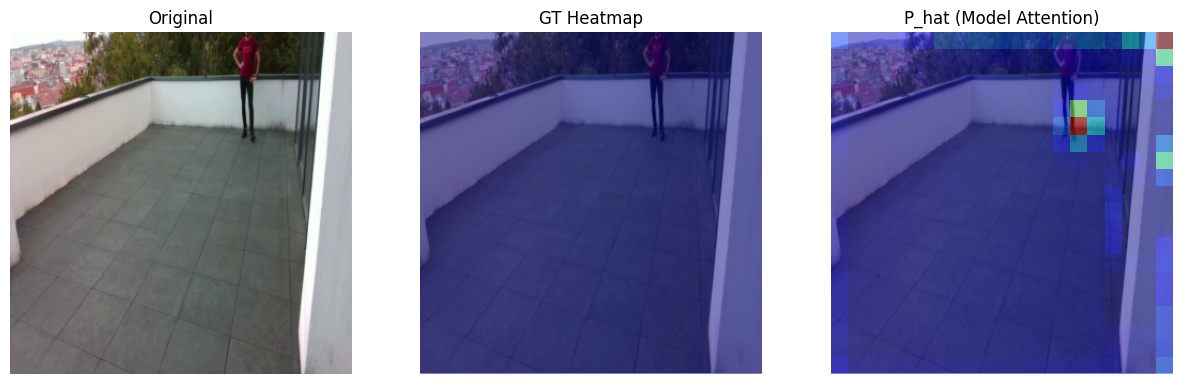

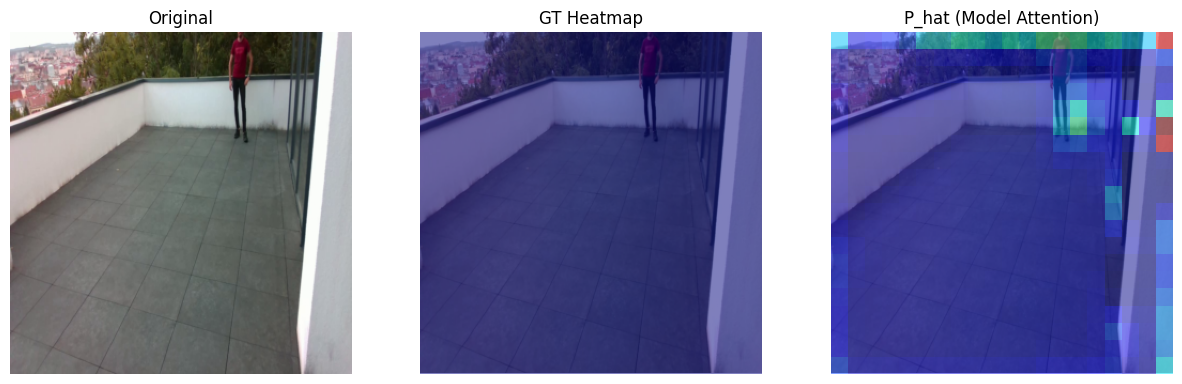

--- TRAINING ENDED ---


In [57]:
# --- Train ---
model = MoCA_BG_DETR().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = Criterion()

def train_one_epoch():
    model.train()
    total_loss = 0

    for img, prev, target in dataloader:
        img = img.to(DEVICE)
        prev = prev.to(DEVICE)

        outputs = model(img, prev)
        loss = criterion(outputs, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss


print("--- TRAINING STARTED ---")

for epoch in range(EPOCHS):
    start_time = time.time()

    loss = train_one_epoch()

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch}: Loss = {loss:.4f} | {epoch_time/60:.2f} min")

visualize_predictions(model, dataloader)
print("--- TRAINING ENDED ---")

In [38]:
# --- Save ---
torch.save(model, MODEL_SAVE_PATH)
print("Model saved.")

Model saved.
